In [49]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import torch
import numpy as np
from pathlib import Path

[[0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.        ]
 [0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.
  0.         0.         0.         0.         0.         0.


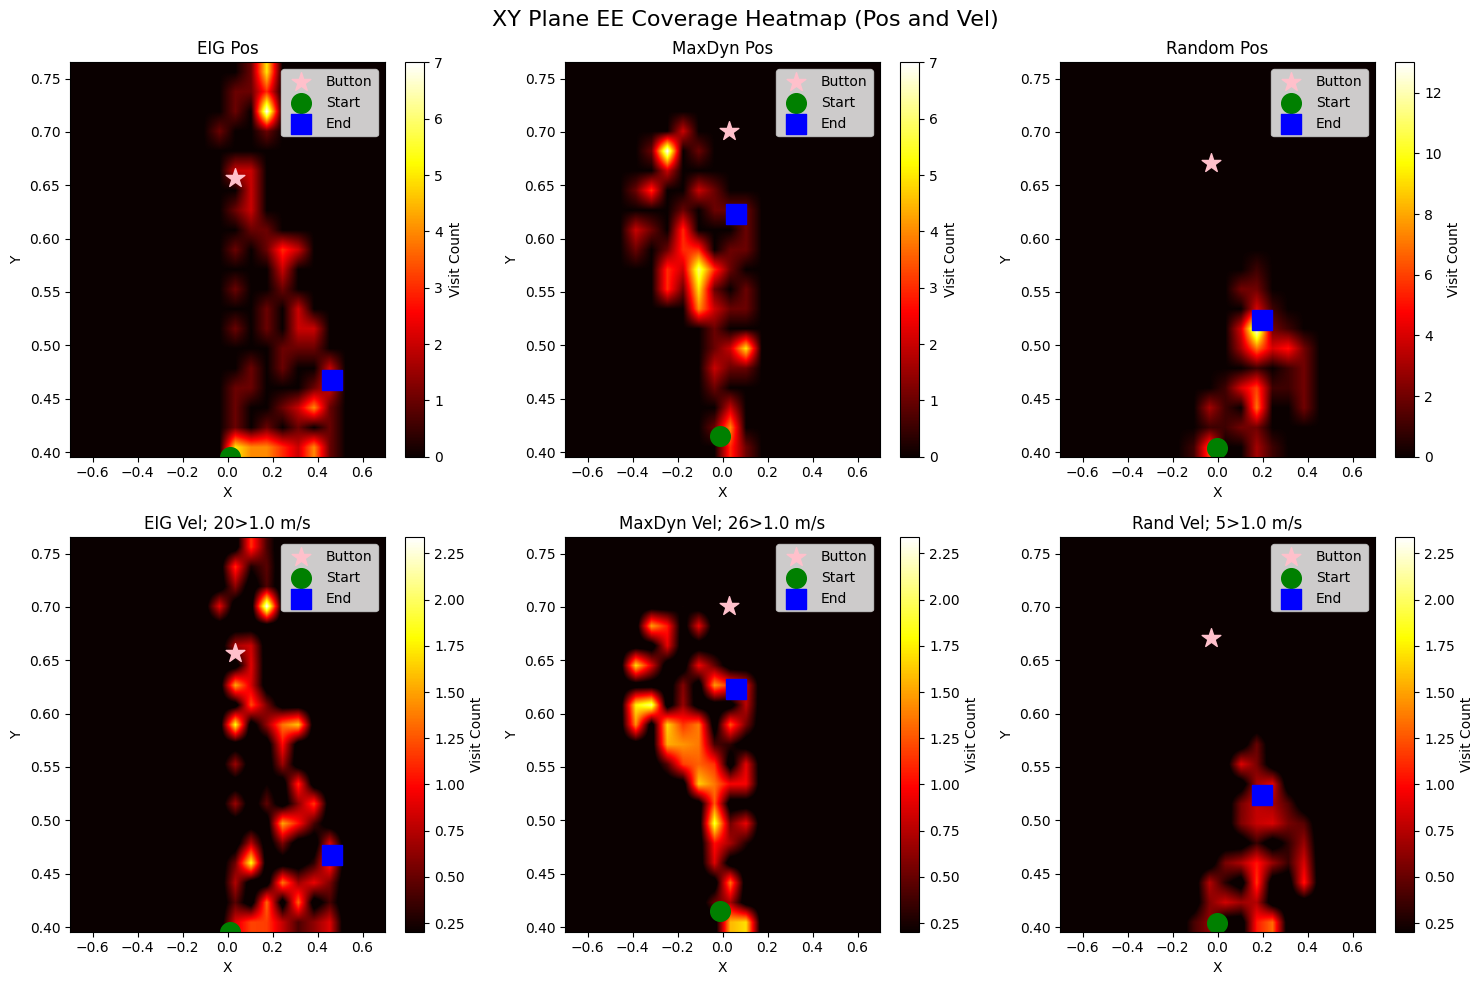

In [75]:
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "src" else Path.cwd()
eig_path = 'runs/button/2026-01-25_03-49-06'
maxdyn_path = 'runs/button/2026-01-25_07-43-20'
rand_path = 'runs/button/2026-01-25_10-23-57'

paths = [eig_path, maxdyn_path, rand_path]
titles = ['EIG Pos', 'MaxDyn Pos', 'Random Pos']

# Load all states to calculate global limits
states = [torch.load(PROJECT_ROOT / path / 'eval_state.pt') for path in paths]

# Calculate global min/max for X and Y
# x_min = min(state[:, 0].min() for state in states)
# x_max = max(state[:, 0].max() for state in states)
y_min = min(state[:, 1].min() for state in states)
y_max = max(state[:, 1].max() for state in states)
x_max = 0.7
x_min = -0.7
num_bins = 20

fig_spatial, axes_spatial = plt.subplots(2, 3, figsize=(15, 10))
fig_spatial.suptitle('XY Plane EE Coverage Heatmap (Pos and Vel)', fontsize=16)

for idx, (state, title) in enumerate(zip(states, titles)):
    hist_xy, xedges, yedges = np.histogram2d(state[:, 0], state[:, 1], bins=num_bins, 
                                              range=[[x_min, x_max], [y_min, y_max]])
    extent_xy = [x_min, x_max, y_min, y_max]
    im_xy = axes_spatial[0, idx].imshow(hist_xy.T, extent=extent_xy, origin='lower', 
                                     cmap='hot', aspect='auto', interpolation='bilinear')
    axes_spatial[0, idx].scatter(state[0, 6], state[0, 7], color='pink', s=200, label='Button', marker='*')
    axes_spatial[0, idx].scatter(state[0, 0], state[0, 1], color='green', s=200, label='Start', marker='o')
    axes_spatial[0, idx].scatter(state[-1, 0], state[-1, 1], color='blue', s=200, label='End', marker='s')
    axes_spatial[0, idx].set_xlabel('X')
    axes_spatial[0, idx].set_ylabel('Y')
    axes_spatial[0, idx].set_xlim(x_min, x_max)
    axes_spatial[0, idx].set_ylim(y_min, y_max)
    axes_spatial[0, idx].set_title(title)
    axes_spatial[0, idx].legend()
    cbar_xy = plt.colorbar(im_xy, ax=axes_spatial[0, idx])
    cbar_xy.set_label('Visit Count')

# Get max and min average velocities globally
vel_min = float('inf')
vel_max = float('-inf')
for state in states:
    hist_vel_sum, _, _ = np.histogram2d(state[:, 0], state[:, 1], bins=num_bins, 
                                        range=[[x_min, x_max], [y_min, y_max]],
                                        weights=np.linalg.norm(state[:,3:6], axis=1))
    hist_counts, _, _ = np.histogram2d(state[:, 0], state[:, 1], bins=num_bins, 
                                       range=[[x_min, x_max], [y_min, y_max]])
    hist_avg = np.divide(hist_vel_sum, hist_counts, where=hist_counts>0, out=np.zeros_like(hist_vel_sum))
    vel_min = min(vel_min, hist_avg[hist_avg > 0].min())
    vel_max = max(vel_max, hist_avg.max())

vel_titles = ['EIG Vel', 'MaxDyn Vel', 'Rand Vel']
high_thresh = 1.0
for idx, (state, title) in enumerate(zip(states, vel_titles)):
    # Get sum of velocities in each location
    hist_vel_sum, xedges, yedges = np.histogram2d(state[:, 0], state[:, 1], bins=num_bins, 
                                                   range=[[x_min, x_max], [y_min, y_max]],
                                                   weights=np.linalg.norm(state[:,3:6], axis=1))
    hist_counts, _, _ = np.histogram2d(state[:, 0], state[:, 1], bins=num_bins, 
                                       range=[[x_min, x_max], [y_min, y_max]])  # Get couunts
    hist_avg_vel = np.divide(hist_vel_sum, hist_counts, where=hist_counts>0, out=np.zeros_like(hist_vel_sum)) # Average velocity by num visits

    print(hist_avg_vel)
    num_high = np.count_nonzero(hist_avg_vel > high_thresh)
    
    extent_xy = [x_min, x_max, y_min, y_max]
    im_xy = axes_spatial[1, idx].imshow(hist_avg_vel.T, extent=extent_xy, origin='lower', 
                                     cmap='hot', aspect='auto', interpolation='bilinear',
                                     vmin=vel_min, vmax=vel_max)
    axes_spatial[1, idx].scatter(state[0, 6], state[0, 7], color='pink', s=200, label='Button', marker='*')
    axes_spatial[1, idx].scatter(state[0, 0], state[0, 1], color='green', s=200, label='Start', marker='o')
    axes_spatial[1, idx].scatter(state[-1, 0], state[-1, 1], color='blue', s=200, label='End', marker='s')
    axes_spatial[1, idx].set_xlabel('X')
    axes_spatial[1, idx].set_ylabel('Y')
    axes_spatial[1, idx].set_xlim(x_min, x_max)
    axes_spatial[1, idx].set_ylim(y_min, y_max)
    axes_spatial[1, idx].set_title(title + f'; {num_high}>{high_thresh} m/s')
    axes_spatial[1, idx].legend()
    cbar_xy = plt.colorbar(im_xy, ax=axes_spatial[1, idx])
    cbar_xy.set_label('Visit Count')

plt.tight_layout()
plt.show()

State shape: torch.Size([100, 9])
EE positions shape: (100, 3)
First few positions:
[[0.01270536 0.39567065 0.14302582]
 [0.02251691 0.40340715 0.13855709]
 [0.01554113 0.40049746 0.13638333]
 [0.01502226 0.39978003 0.11934534]
 [0.0155666  0.40117092 0.10419733]]
Min/Max values: X(-0.017, 0.464), Y(0.396, 0.765), Z(0.008, 0.321)


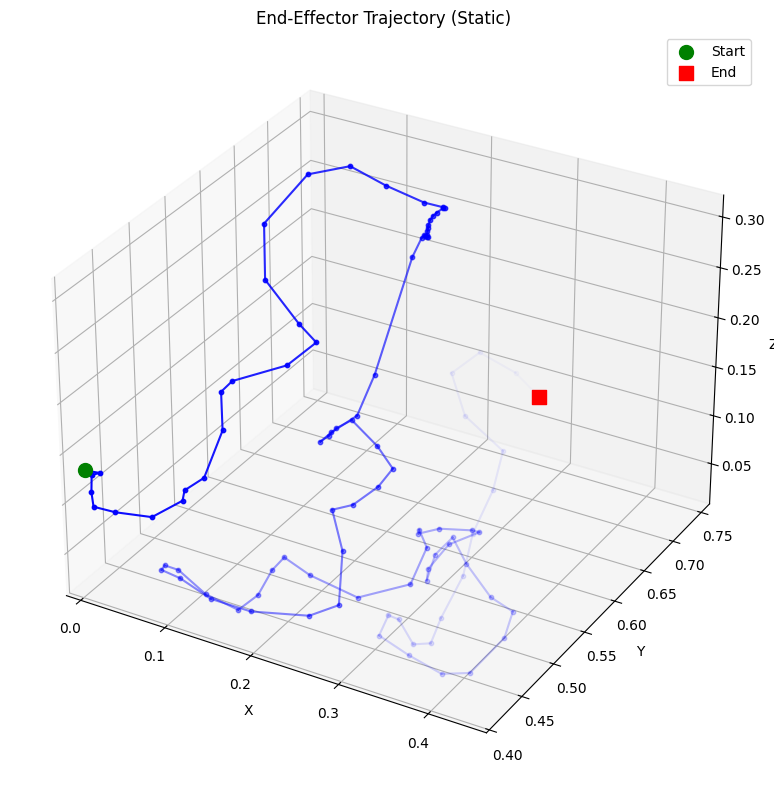

In [79]:


PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "src" else Path.cwd()
run_path = eig_path

# Load saved state
state = torch.load(PROJECT_ROOT / run_path / 'eval_state.pt')
print(f"State shape: {state.shape}")

# Convert to numpy
ee_positions = state[:, 0:3]
if isinstance(ee_positions, torch.Tensor):
    ee_positions = ee_positions.cpu().numpy()

print(f"EE positions shape: {ee_positions.shape}")
print(f"First few positions:\n{ee_positions[:5]}")
print(f"Min/Max values: X({ee_positions[:, 0].min():.3f}, {ee_positions[:, 0].max():.3f}), "
      f"Y({ee_positions[:, 1].min():.3f}, {ee_positions[:, 1].max():.3f}), "
      f"Z({ee_positions[:, 2].min():.3f}, {ee_positions[:, 2].max():.3f})")

x, y, z = ee_positions[:, 0], ee_positions[:, 1], ee_positions[:, 2]

# Create static 3D plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Plot trajectory with decreasing alpha
# First plot connecting lines with decreasing alpha
for i in range(len(x) - 1):
    alpha = 1.0 - (i / len(x))  # starts at 1, decreases to ~0
    ax.plot(x[i:i+2], y[i:i+2], z[i:i+2], color='blue', linewidth=1.5, alpha=alpha)

# Then plot points with decreasing alpha
for i in range(len(x)):
    alpha = 1.0 - (i / len(x))  # starts at 1, decreases to ~0
    ax.scatter(x[i], y[i], z[i], color='blue', s=10, alpha=alpha)
    
ax.scatter(x[0], y[0], z[0], color='green', s=100, label='Start', marker='o')
ax.scatter(x[-1], y[-1], z[-1], color='red', s=100, label='End', marker='s')

ax.set_xlim(x.min(), x.max())
ax.set_ylim(y.min(), y.max())
ax.set_zlim(z.min(), z.max())

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.set_title('End-Effector Trajectory (Static)')
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.show()